In [2]:
import numpy as np
import jax
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob

os.chdir("/home/ihuarte/Escritorio/Ivan")

# from ATMOS_VA.VA_project.src.VA_project.model.model import OxalateJKGamma
# from ATMOS_VA.VA_project.src.VA_project.engine.runners import Runner

#from NN_utils import load_vstate
#from correlations import correlations_vstate

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")
jax.devices()

[CpuDevice(id=0)]

In [ ]:
import re

fontsize_txt=12
fontsize_title=20
fontsize_labels=15
fontsize_legend=13

parent= "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/LRChain_CvT3"
parent_folder = parent if parent.endswith("/") else parent + "/"
all_subdirs = []
for root, dirs, files in os.walk(parent_folder):
    for d in dirs:
        all_subdirs.append(os.path.join(root, d))

all_subdirs

sweep_cleaning = set([os.path.basename(folder) for folder in all_subdirs])
sweep_cases = [name for name in sweep_cleaning if 'sweeps_' in name ]

tree_files = dict((k ,{}) for k in sweep_cases)
for sweep in sweep_cases:
    sizes = glob.glob(parent_folder + f"**/{sweep}")
    for size in sizes:
        # pos = size.find("Size_")
        # size_name = size[pos +len("Size_"):pos +len("Size_") + 3]
        size_name = re.search(r"Size_([0-9]+x[0-9]+)",size).group(1)
        json_objects = glob.glob(size +'/*.json')
        alphas = set([re.search(r"alpha_([\d\.]+)", file).group(0) for file in json_objects])

        for alpha in alphas:
            alpha_files = [file for file in json_objects if alpha in file]
            if not alpha in tree_files[sweep].keys(): tree_files[sweep][alpha]={}
            tree_files[sweep][alpha][size_name] = alpha_files

model_name = os.path.basename(parent).replace("_", "-")

for sweep, sweep_dict in tree_files.items():

    for alpha, alpha_dict in sweep_dict.items():

        fig1, ax1 = plt.subplots(3,1,figsize=[12,20])
        fig2, ax2 = plt.subplots(3,1,figsize=[12,20])
        fig3, ax3 = plt.subplots(2,1,figsize=[10,12])

        for size, files in alpha_dict.items():
            
            results =[[] for _ in range(10)] # For [J, E_best, E_ED, error, vscore, S_renyi, M, Ms, fidelity, timexe]

            for file in files:
                # Load artifacts and simulation params
                with open(file,'r') as f:
                    art = json.load(f)
                # print(art['coupling_model']['J'])
                results[0].append(art['coupling_model']['J'])
                results[1].append(art['results']['E_best'])
                results[2].append(art['results']['E_ED'])
                results[3].append(art['results']['error'])
                results[4].append(art['results']['vscore'])
                results[5].append(art['results']['S_renyi'])
                results[6].append(art['results']['M'])
                results[7].append(art['results']['Ms'])
                results[8].append(art['results']['fidelity'])
                results[9].append(art['results']['time_exe'])

            alpha = art['coupling_model']['alpha']

            results = np.array(results)
            idx = np.argsort(results[0])
            res = results[:,idx]

            # Plot 1: E_best/E_ED, error, vscore
            ax1[0].set_title(r"$%s$"%(model_name) + r"        $\alpha=%.2f$ "%(alpha), fontsize=fontsize_title)
            ax1[0].set_ylabel(r"$Energy$", fontsize=fontsize_labels)
            ax1[0].plot(res[0], res[1], color='blue', alpha=0.8, marker='o', ms=3, lw=1.5, label=r"$E\;(%s)$"%(size))
            ax1[0].plot(res[0], res[2], color='lime',ls='--', marker='o', ms=3, lw=1.5, alpha=0.8, label=r"$E_{ED}\; (%s)$"%(size))
            ax1[0].grid()
            ax1[0].legend(fontsize=fontsize_legend)

            ax1[1].set_ylabel(r"$rel.\;\;Error$",fontsize=fontsize_labels)
            ax1[1].plot(res[0], res[3], color='red', alpha=0.8, marker='o', ms=3, lw=1.5,  label=r"$%s$"%(size))
            ax1[1].set_yscale('log')
            ax1[1].grid()
            ax1[1].legend(fontsize=fontsize_legend)
            
            ax1[2].set_ylabel(r"$Vscore$", fontsize=fontsize_labels)
            ax1[2].set_xlabel(r"$J$", fontsize=fontsize_labels)
            ax1[2].plot(res[0], res[4], color='purple',marker='o', ms=3 , lw=1.5, alpha=0.8,   label=r"$%s$"%(size))
            ax1[2].set_yscale('log')
            ax1[2].grid()
            ax1[2].legend(fontsize=fontsize_legend)

            # Plot 2: Renyi-entropy,  Magnetization and fluctuation
            ax2[0].set_title(r"$%s$"%(model_name) + r"        $\alpha=%.2f$ "%(alpha), fontsize=fontsize_title)
            ax2[0].set_ylabel(r"$S_{renyi}$", fontsize=fontsize_labels)
            ax2[0].plot(res[0], res[5], color='green', alpha=0.8, marker='o', ms=3, lw=1.5, label=r"$%s$"%(size))
            ax2[0].grid()
            ax2[0].legend(fontsize=fontsize_legend)

            ax2[1].set_ylabel(r"$Magnetization\;\;(M_z)$",fontsize=fontsize_labels)
            ax2[1].plot(res[0], res[6], color='red', alpha=0.8, marker='o', ms=3, lw=1.5,  label=r"$%s$"%(size))
            ax2[1].grid()
            ax2[1].legend(fontsize=fontsize_legend)

            ax2[2].set_ylabel(r"$Fluctuations\;\;(M_s)$", fontsize=fontsize_labels)
            ax2[2].set_xlabel(r"$J$", fontsize=fontsize_labels)
            ax2[2].plot(res[0], res[7], color='purple',marker='o', ms=3 , lw=1.5, alpha=0.8,   label=r"$%s$"%(size))
            ax2[2].grid()
            ax2[2].legend(fontsize=fontsize_legend)

            # Plot 3: Fidelity and Time Execution
            ax3[0].set_title(r"$%s$"%(model_name) + r"        $\alpha=%.2f$ "%(alpha), fontsize=fontsize_title)
            ax3[0].set_ylabel(r"$Fidelity$", fontsize=fontsize_labels)
            ax3[0].plot(res[0], res[8], color='darkorange', alpha=0.8, marker='o', ms=3, lw=1.5, label=r"$%s$"%(size))
            ax3[0].grid()
            ax3[0].legend(fontsize=fontsize_legend)

            ax3[1].set_ylabel(r"$TimeExe\;('')$",fontsize=fontsize_labels)
            ax3[1].set_xlabel(r"$J$", fontsize=fontsize_labels)
            ax3[1].plot(res[0], res[9], color='olivedrab', alpha=0.8, marker='o', ms=3, lw=1.5,  label=r"$%s$"%(size))
            ax3[1].grid()
            ax3[1].legend(fontsize=fontsize_legend)
        fig1.tight_layout()
        fig2.tight_layout()
        fig3.tight_layout()

        fig1.savefig(parent_folder + f"ResultsOfSweep_alpha_{alpha}_Energy_Error_Vscore" + ".jpeg", dpi=600, bbox_inches="tight")
        fig2.savefig(parent_folder + f"ResultsOfSweep_alpha_{alpha}_Renyi_Mz_Ms" + ".jpeg", dpi=600, bbox_inches="tight")
        fig3.savefig(parent_folder + f"ResultsOfSweep_alpha_{alpha}_Fidelity_Timexe" + ".jpeg", dpi=600, bbox_inches="tight")





In [ ]:
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/LRChain_CvT3/Size_20x1/sweeps_0/LRChain_CvT3_results_20x1_J_6.0_alpha_4.0_XZ_-1.0_0.0_blocks_2_emb_ch_32_cp_ch_32_heads_4_kernel_3x1_finarch_128_5_.json"



In [ ]:
import re

In [ ]:

#os.chdir("/home/ihuarte/Escritorio/Ivan/NNs/")
%run ./SplitTraining_simulation_LRChain.py

In [ ]:
np.abs(np.vdot(vstate.to_array(),x_ED.squeeze()))

In [ ]:
import netket.experimental as nkx
hi = vstate.hilbert
N = vstate.hilbert.size
renyi = nkx.observable.Renyi2EntanglementEntropy(
    hi, np.arange(0, N / 2 + 1, dtype=int)
)
mags = sum([(-1) ** (i) * sigmaz(hi, i) /N for i in range(N)])
magnet = sum([sigmaz(hi, i) / N for i in range(N)])

In [ ]:
M_stats = vstate.expect(magnet)
M, M_var = float(M_stats.mean.real), float(M_stats.variance.real)
Ms = M_var + M**2

In [ ]:
M,M_var, Ms

In [ ]:
vstate.expect(magnet), vstate.expect(mags)

3.345042765875381e-07


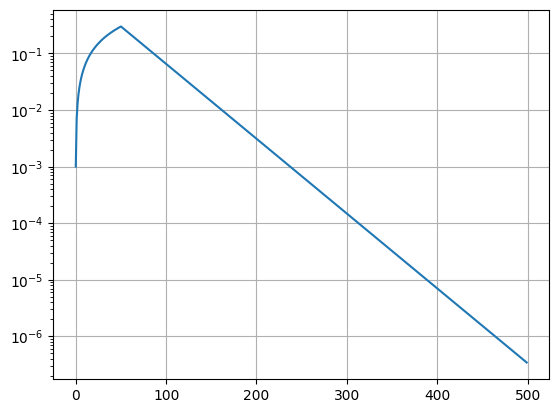

In [4]:
epochs=500

fun=optax.warmup_exponential_decay_schedule(
            init_value=.001,
            peak_value=0.3,
            warmup_steps=50,
            transition_steps=1,
            decay_rate=0.97,
        )

print(fun(epochs))
x=np.arange(0,epochs)
y=fun(x)

_, ax = plt.subplots()
ax.plot(x, y)
ax.set_yscale('log')
ax.grid()

In [ ]:
a="/home/ihuarte/afwkcmlcn/afljnafu/Holaquetal.json"
os.path.basename(a)
os.path.dirname(a)

In [ ]:
oxa=OxalateJKGamma(
    [4,5], 
    [0.2, 9.0, 72.0],
    **{'bc': 'periodic', 'order': 'default_2'}
)
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(k=5, eigenstates=True)

In [ ]:
art_path='/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate_SplitTraining_ViT_CNN/Size_4x5/sweeps_0/Oxalate_SplitTraining_ViT_CNN_results_4x5_strength_0.2_theta_9.0_phi_72.0_channels_32_kernel_3x3_n_ffn_lay_1.json'

with open(art_path,'r') as f:
    artifact = json.load(f)

In [ ]:
x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/prueba/JKGamma/Split_oxalate_CNN/Oxalate_size_4x4/sweeps_20/Oxalate_xED_4x4_strength_0.2_theta_9.0_phi_72.0_ED.txt", dtype=complex)
x_vs = np.array(vstate.to_array())

In [ ]:



mod_vs, phase_vs, stats_vs = modphase(x_vs)
mod_ED, phase_ED, stats_ED = modphase(x_ED)



In [ ]:
a=(383,339)
print(f"|| {a} ||")

In [ ]:
import matplotlib.transforms as mtransforms
_,ax= plt.subplots(4,1, figsize=[15,10])

ax[0].set_title(r"$Modulus\;and\;Phase\qquad Oxalate\;size\;%d x %d \qquad a=%.1f\;\;\theta=%.1f \;\; \phi=%.1f$"%(4,4,0.2,9.0,72.0))
ax[0].set_xticks([])
ax[0].set_ylabel(r"$Modulus$")
ax[0].set_ylim(-0.01,max(max(mod_ED),max(mod_vs))*9/8)
ax[0].plot(mod_vs, alpha=0.6, color='r', label='vstate')
ax[0].plot(mod_ED, alpha=0.6, label='ED')
ax[0].legend()

ax[1].set_xticks([])
ax[1].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[1].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[1].set_ylabel(r"$Phase \;vstate$")
ax[1].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[1].plot(phase_vs, alpha=0.25, ls='', marker='o', ms=0.9, color='r', label='vstate')
ax[1].legend(loc='upper right')

ax[2].set_xlabel(r"$C_i$")
ax[2].set_ylabel(r"$Phase \;ED$")
ax[2].set_ylim(-np.pi-0.1, np.pi+0.1)
ax[2].set_yticks([-np.pi,-np.pi/2,0,np.pi/2,np.pi])
ax[2].set_yticklabels([r"$-\pi$",r"$-\pi/2$",r"$0$",r"$\pi/2$",r"$\pi$"])
ax[2].plot(phase_ED, alpha=0.25, ls='', marker='o', ms=0.9, label='ED')
ax[2].legend(loc='upper right')

ax[3].set_xlabel(r"$Phase\;(radians)$")
ax[3].set_ylabel(r"$Phase \;histogram$")
ax[3].hist(phase_ED, bins=1000, range=(-np.pi, np.pi), density=True, alpha=0.7, label='ED')
ax[3].hist(phase_vs, bins=1000, range=(-np.pi, np.pi), color='r', density=True, alpha=0.7, label='vstate')


transform = mtransforms.blended_transform_factory(ax[3].transData, ax[3].transAxes)
if stats_ED['peaks'] is not None:
    for peak in stats_ED['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)

if stats_vs['peaks'] is not None:
    for peak in stats_vs['peaks']['values']:
        ax[3].text(peak-0.1, 0.9, r"%.2f"%peak, color='b', transform=transform, fontsize=8, alpha=0.7)
ax[3].legend()
plt.tight_layout()
plt.savefig(write_folder + files[j] + ".jpeg", dpi=600, bbox_inches="tight")

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(lr_schedule, marker='o',ls=None, label='Learning Rate Schedule')
ax.set_xlabel('Epochs')
ax.set_ylabel('Learning Rate')

In [ ]:
from VA_project.lattice.lattice import Chain,Square
from VA_project.model.cm import GeneralNeighborCoupling

size=[4,5]

fields=[(0., 'X'), (0.5, 'Z'), (0.8, 'Y')]
couplings=[(0.,'ZZ','NN'),(2.,'YY','NN2')]

chain= Square(*size,bc='periodic', order= 'default_1')
ZZYY= GeneralNeighborCoupling(chain, fields, couplings)
chain.plot_lattice(1)

In [ ]:
from NN_module.NN_utils import traslations_2D,traslations_2D_scan,traslations_2D_vmap

In [ ]:
a=jnp.arange(20)
size=[4,5]
token_size=[2,1]
sub_lat=[size[0]//token_size[0], size[1]//token_size[1]]
# a.reshape((sub_lat[1],token_size[1],sub_lat[0],token_size[0]),
#                   order='C').transpose((0, 2, 1, 3)).reshape(-1,token_size[0]*token_size[1]).squeeze()
#traslations_2D_scan(a,size).reshape(-1,*size)
traslations_2D(a,size, memory=False)#.reshape(-1,*size)



In [ ]:
import sys
from pathlib import Path
sys.path.append(str("/home/ihuarte/Escritorio/Ivan/ATMOS_VA/VA_project/src"))

from VA_project.model.model import OxalateJKGamma
from VA_project.engine.runners import Runner
from NN_module.sim_utils import (
    load_vstate
)
files=[
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_128_heads_2_blocks_2_ffn_lay_2.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_8_blocks_2_ffn_lay_4.json",
    "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/targets/Oxalate_results_4x4_strength_0.2_theta_54.0_phi_0.0_b_2x2_Demb_64_heads_2_blocks_2_ffn_lay_4.json"
]

size=[4,4]
strength=0.2
theta=54.
phi=0.
kwargs_lattice={
    'bc':'periodic',
    'order':'default_2'
}

oxa=OxalateJKGamma(
            size, 
            [strength, theta, phi],
            **kwargs_lattice
        )
H = Runner(oxa.cm).build_hamiltonian()
E_ED, x_ED = Runner(oxa.cm).exact_energy_lanczos(eigenstates=True, k=150)
idx=np.argsort(E_ED)
E_ED=E_ED[idx]
x_ED=x_ED.T[idx,:]

In [ ]:
i=2
path_artifact= files[i]

with open(path_artifact,'r') as f:
    artifact = json.load(f)

vstate=load_vstate(artifact).to_array()
vstate=np.array(vstate, dtype=np.complex128)


In [ ]:
c=np.sum(x_ED.conjugate()*vstate, axis=1)
P=np.abs(c)**2
sum(P)

In [ ]:
E_best=artifact['results']['E_best']
e=-np.inf; idx=0
while e<E_best:
    e=E_ED[idx]
    idx+=1

idx, E_ED[idx],E_ED[idx-1]

In [ ]:
P_sum=sum(P)

_,ax=plt.subplots()
ax.set_title(f"Projections #{i}")
ax.set_xlabel("Eigenstates")
ax.set_ylabel("Probability")
ax.bar(range(len(P)), P, label=r"$\Sigma_i\; P_i$")
ax.vlines(idx, 0,max(P), color='r', ls='--', label=r"$\sim E_{sim}$")
ax.legend(fontsize=8)
ax.text(0.5, 0.8, r"$\Sigma_i\; P_i = %.4f$"%P_sum+"\n"+r"$E_1=%.3f$"%E_ED[0]+"\n"+r"$E_{150}=%.3f$"%(E_ED[-1])+"\n"+r"$E_{sim}=%.3f$"%E_best, transform=ax.transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.4))
#ax.set_yscale('log')

In [ ]:
a=False
b=True
not a and b

# Learning Rate Scheduler

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from NN_module.NN_utils import scheduler_initializer

In [ ]:

schedule={
    'epochs': 500,
    'cos_exp_scheduler':{
        "lr0":0.6,
        "decay_exp":1.,
        "cosine_cycles":2.,
        "n":0.1,
        "lr_min": 0.01
    }
}

lr_sch=scheduler_initializer('cos_exp_scheduler', schedule)


# recta = lambda x: (lr_min-n)/epochs*x+n
# y_recta=recta(jnp.arange(0,epochs))

y=lr_sch(jnp.arange(0,schedule['epochs']))

_,ax= plt.subplots(1,1,figsize=(10,5))
ax.plot(y, label="exp decay")
#ax.plot(np.arange(epochs),y_recta, ls= '--', color='r')
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
#ax.set_ylim(0, 1.05)
ax.legend()
ax.grid()

In [ ]:
21388438632/(1024)**3

In [ ]:
import jax.numpy as jnp
import jax
a= jnp.ones((4,4), dtype=complex)/10
b= jnp.ones((4,4) ,dtype=complex)


stack=jnp.array([a,b]).transpose(1,0,2)
z2_sym=jax.nn.logsumexp(
    stack,
    b=jnp.array([1., -1.])[None,:,None],
    axis=1
)
z2_2d_symm=jax.nn.logsumexp(
    z2_sym,
    axis=0
)

In [ ]:
from flax.serialization import to_bytes, from_bytes
import msgpack
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/ViT_2D/Oxalate_size_4x4/Oxalate_vstate_params_4x4_strength_0.2_theta_90.0_phi_115.2_b_2x1_Demb_64_heads_4_blocks_2_ffn_lay_4.msgpack"

In [ ]:
with open(file, "rb") as f:
    bytes_data = f.read()

# Decodifica con msgpack sin un schema de Flax
unpacked = msgpack.unpackb(bytes_data, raw=False)

import pprint
pprint.pprint(unpacked)


In [ ]:
_, ax= plt.subplots()
x=np.arange(50,300)
ax.set_ylim(0,0.1)
ax.set_xlim(0,300)
ax.plot(x,0.05*0.987**(x-50))

In [ ]:
import numpy as np
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_xED_4x5_strength_0.2_theta_0_phi_0.txt"
x_ED= np.loadtxt(file, dtype=complex)
x_ED

In [ ]:
jnp.angle(x_ED)

In [ ]:
from NN_module.sim_utils import load_vstate
import json
file="/home/ihuarte/Escritorio/Ivan/NNs/Simulations/pruebas_Ising_LRM/LRM/ViT/Oxalate_results_4x5_strength_0.2_theta_0_phi_0_XZ_-1.0_0.001_J_1.5_alpha_2.5_b_2x1_Demb_32_heads_2_blocks_2_ffn_lay_2.json"

In [ ]:
with open(file,'rb') as f:
    conf=json.load(f)

vstate=load_vstate(conf)